# Importando os pacotes

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from collections import defaultdict
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Embedding, Dense, TimeDistributed, Bidirectional, Input
from sklearn.model_selection import train_test_split
from tensorflow.keras.metrics import categorical_accuracy
import tensorflow.keras.backend as K
import tensorflow as tf

# For inline plotting in Jupyter Notebook
%matplotlib inline


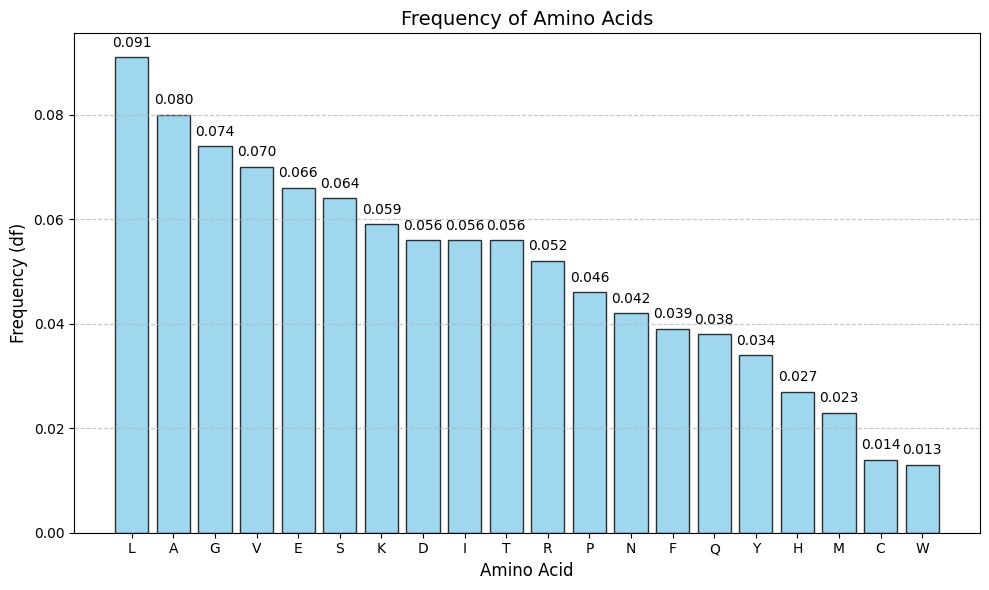

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
data = {
    'Amino Acid': ['L', 'A', 'G', 'V', 'E', 'S', 'K', 'D', 'I', 'T', 
                   'R', 'P', 'N', 'F', 'Q', 'Y', 'H', 'M', 'C', 'W'],
    'df': [0.091, 0.080, 0.074, 0.070, 0.066, 0.064, 0.059, 0.056, 
           0.056, 0.056, 0.052, 0.046, 0.042, 0.039, 0.038, 0.034, 
           0.027, 0.023, 0.014, 0.013]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(df['Amino Acid'], df['df'], color='skyblue', edgecolor='black', alpha=0.8)

# Add labels and title
plt.xlabel('Amino Acid', fontsize=12)
plt.ylabel('Frequency (df)', fontsize=12)
plt.title('Frequency of Amino Acids', fontsize=14)

# Annotate bars with values
for index, value in enumerate(df['df']):
    plt.text(index, value + 0.002, f'{value:.3f}', ha='center', fontsize=10)

# Show grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display plot
plt.tight_layout()
plt.show()


# Exploratory Data Analysis

(477153, 7)


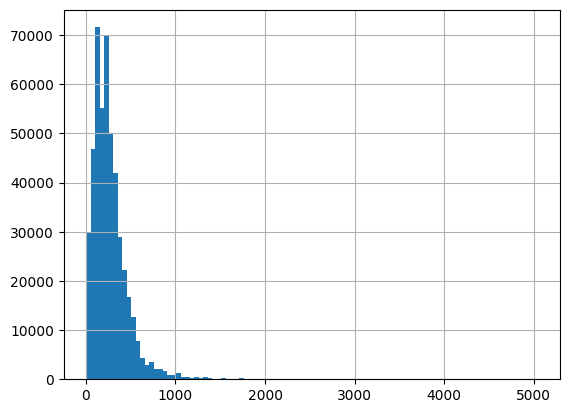

In [3]:
df = pd.read_csv(r"H:\\THESIS\\DATASET\\2022-08-03-ss.cleaned.csv").sort_values(by=['pdb_id','chain_code'])
df.len.hist(bins=100)
print(df.shape)

In [4]:
df.head()

,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa
146703,101M,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,CCCCHHHHHHHHHHHHHHGGGHHHHHHHHHHHHHHHCGGGGGGCTT...,CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCHHHHHHCCC...,154,False
162296,102L,A,MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNAAAKSE...,CCHHHHHHHHHCCEEEEEECTTSCEEEETTEEEESSSCTTTHHHHH...,CCHHHHHHHHHCCEEEEEECCCCCEEEECCEEEECCCCCCCHHHHH...,165,False
146704,102M,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,CCCCHHHHHHHHHHHHHHGGGHHHHHHHHHHHHHHHCGGGGGGCTT...,CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCHHHHHHCCC...,154,False
164681,103L,A,MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNSLDAAK...,CCHHHHHHHHHCCEEEEEECTTSCEEEETTEECCCCCCCCCHHHHH...,CCHHHHHHHHHCCEEEEEECCCCCEEEECCEECCCCCCCCCHHHHH...,167,False
146705,103M,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,CCCCHHHHHHHHHHHHHHGGGHHHHHHHHHHHHHHHCGGGGGGCTT...,CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCHHHHHHCCC...,154,False


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 477153 entries, 146703 to 387996
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   pdb_id         477153 non-null  object
 1   chain_code     477153 non-null  object
 2   seq            477153 non-null  object
 3   sst8           477153 non-null  object
 4   sst3           477153 non-null  object
 5   len            477153 non-null  int64 
 6   has_nonstd_aa  477153 non-null  bool  
dtypes: bool(1), int64(1), object(5)
memory usage: 25.9+ MB
None


The sequence length distribution plot is a visual representation of how frequently different sequence lengths appear in your dataset. Each bar in the histogram represents a length interval, and the bar height indicates how many sequences fall within that interval.

C:\Users\kaush\AppData\Local\Temp\ipykernel_20052\3538544767.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['len'], bins=30, kde=True)


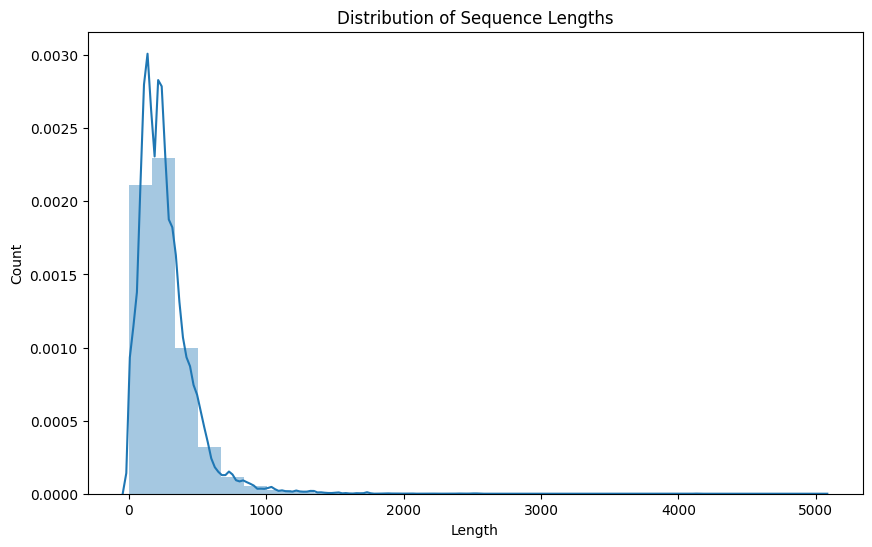

In [6]:
# Visualization of sequence length distribution
plt.figure(figsize=(10, 6))
sns.distplot(df['len'], bins=30, kde=True)
plt.title('Distribution of Sequence Lengths')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()


C:\Users\kaush\AppData\Local\Temp\ipykernel_20052\2115135258.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='has_nonstd_aa', data=df, palette='pastel')


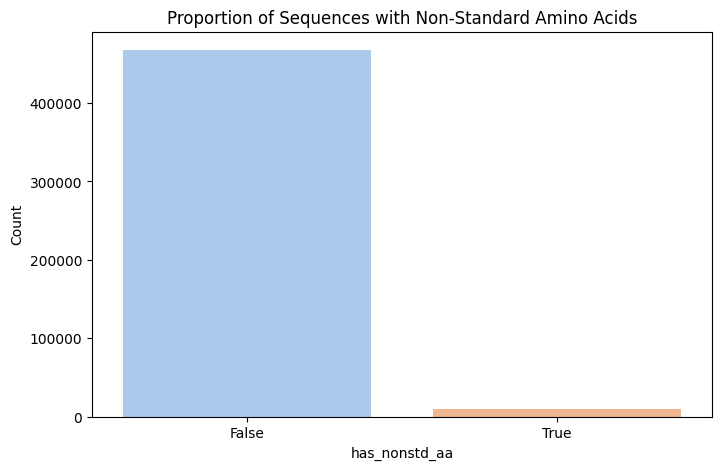

In [7]:
# Visualization of sequences proportion with non-standard amino acids
plt.figure(figsize=(8, 5))
sns.countplot(x='has_nonstd_aa', data=df, palette='pastel')
plt.title('Proportion of Sequences with Non-Standard Amino Acids')
plt.xlabel('has_nonstd_aa')
plt.ylabel('Count')
plt.show()

C:\Users\kaush\AppData\Local\Temp\ipykernel_20052\2113533992.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='has_nonstd_aa', data=df, palette='pastel')


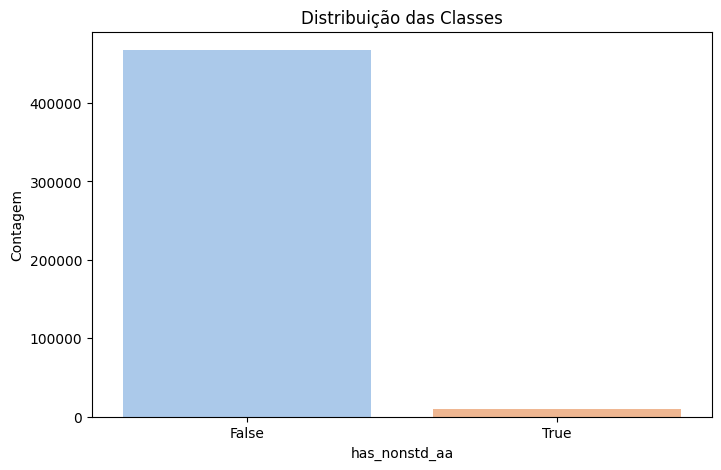

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='has_nonstd_aa', data=df, palette='pastel')
plt.title('Distribuição das Classes')
plt.xlabel('has_nonstd_aa')
plt.ylabel('Contagem')
plt.show()


C:\Users\kaush\AppData\Local\Temp\ipykernel_20052\1323546908.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='has_nonstd_aa', y='len', data=df, palette='pastel')


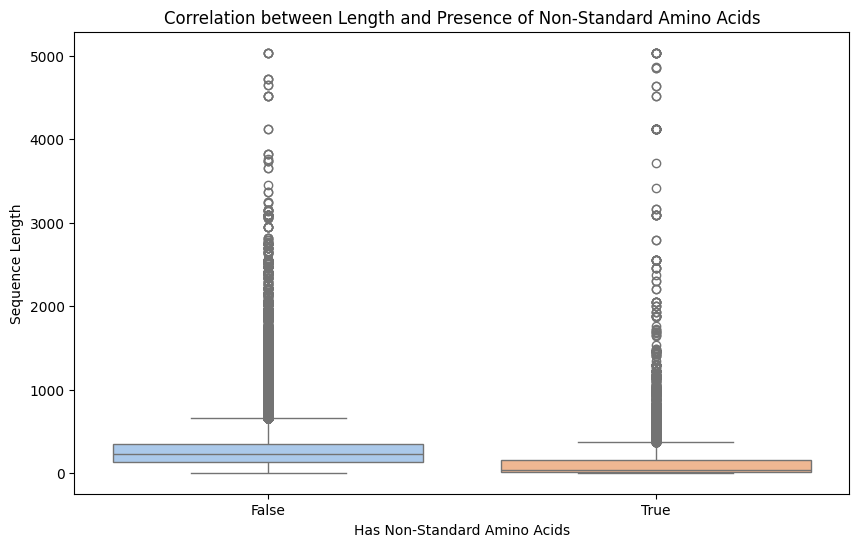

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='has_nonstd_aa', y='len', data=df, palette='pastel')
plt.title('Correlation between Length and Presence of Non-Standard Amino Acids')
plt.xlabel('Has Non-Standard Amino Acids')
plt.ylabel('Sequence Length')
plt.show()


In [7]:
shortest_sequences = df[df['len'] == df['len'].min()]
longest_sequences = df[df['len'] == df['len'].max()]

print("Shortest sequences:")
print(shortest_sequences)

print("\nLongest sequences:")
print(longest_sequences)


Shortest sequences:
    pdb_id chain_code  seq sst8 sst3  len  has_nonstd_aa
0     1A30          C  EDL  CBC  CEC    3          False
1     1B05          B  KCK  CBC  CEC    3          False
2     1B0H          B  KAK  CBC  CEC    3          False
3     1B1H          B  KFK  CBC  CEC    3          False
4     1B2H          B  KAK  CBC  CEC    3          False
..     ...        ...  ...  ...  ...  ...            ...
164   6JFO          B  MAS  CBC  CEC    3          False
165   6PJ4          B  VRM  CBC  CEC    3          False
166   6R0Q          E  ***  CBC  CEC    3           True
167   6R0Q          F  ***  CBC  CEC    3           True
168   8GCH          C  GAW  CBC  CEC    3          False

[169 rows x 7 columns]

Longest sequences:
       pdb_id chain_code                                                seq  \
477141   4UWA          A  MGDGGEGEDEVQFLRTDDEVVLQCSATVLKEQLKLCLAAEGFGNRL...   
477142   4UWA          B  MGDGGEGEDEVQFLRTDDEVVLQCSATVLKEQLKLCLAAEGFGNRL...   
477143   4UWA  

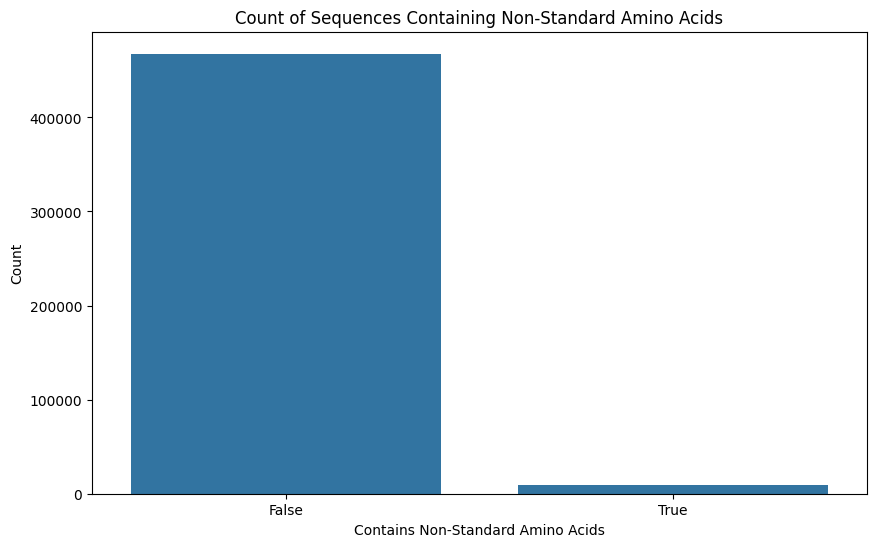

In [11]:
# Display count of sequences containing non-standard amino acids
plt.figure(figsize=(10,6))
sns.countplot(x='has_nonstd_aa', data=df)
plt.title('Count of Sequences Containing Non-Standard Amino Acids')
plt.xlabel('Contains Non-Standard Amino Acids')
plt.ylabel('Count')
plt.show()

C:\Users\kaush\AppData\Local\Temp\ipykernel_6596\3715692803.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show() # Display the figure


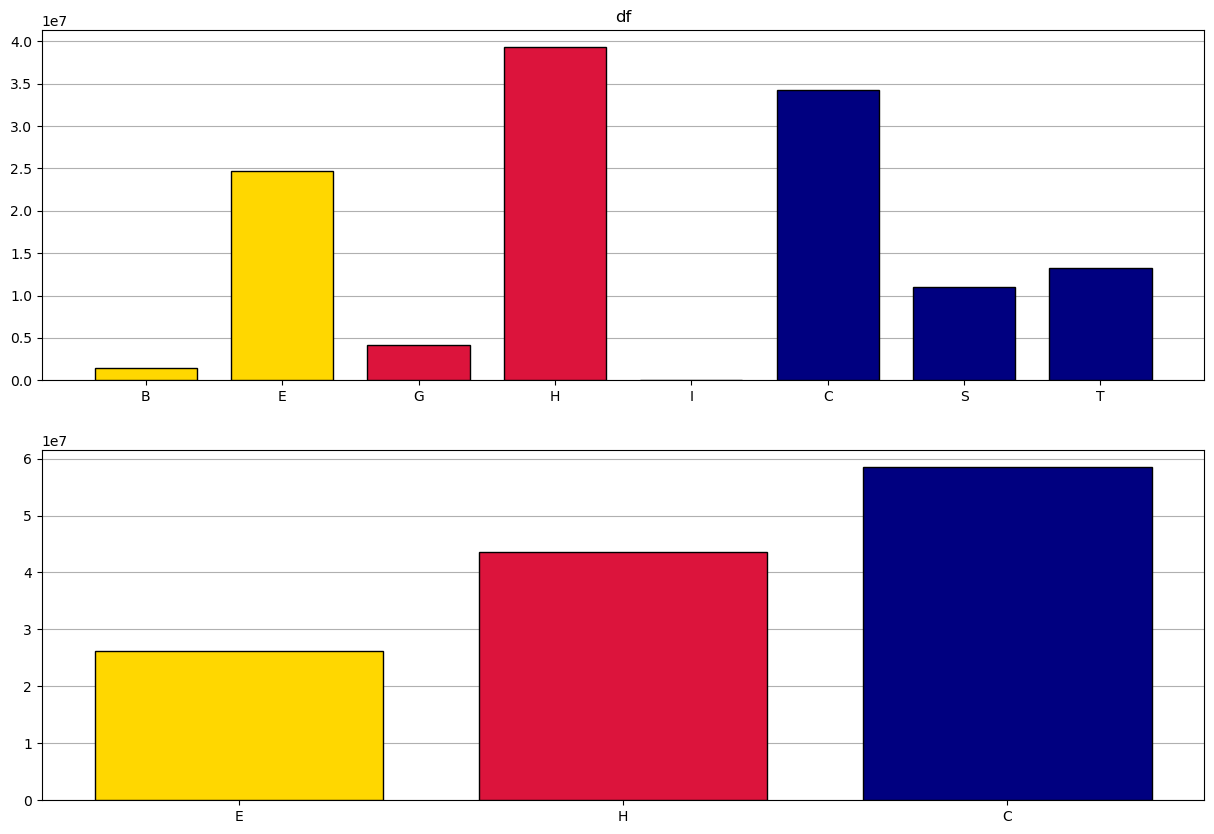

In [8]:
# Configure storage for DataFrame df
SS_counts = {'df': {'SST-8': defaultdict(lambda: 0), 'SST-3': defaultdict(lambda: 0)}}

# Count types for DataFrame df
for seq in df['sst8']:
    for ss in set(seq):
        SS_counts['df']['SST-8'][ss] += seq.count(ss)
        
for seq in df['sst3']:
    for ss in set(seq):
        SS_counts['df']['SST-3'][ss] += seq.count(ss)

# Define order for ss types
ss8_types = ['B', 'E', 'G', 'H', 'I', 'C', 'S', 'T']
ss3_types = ['E', 'H', 'C']

sst8_colors = ['gold', 'gold', 'crimson', 'crimson', 'crimson', 'navy', 'navy', 'navy']
sst3_colors = ['gold', 'crimson', 'navy']

fig, axs = plt.subplots(2, 1, sharey = 'row', figsize = (15, 10))

axs[0].bar(range(8), height = [SS_counts['df']['SST-8'][ss] for ss in ss8_types],
          tick_label = ss8_types, edgecolor = 'black', width = 0.75, zorder = 3, color = sst8_colors)
axs[0].grid(axis = 'y', which = 'both', zorder = 0)
axs[0].title.set_text('df')

axs[1].bar(range(3), height = [SS_counts['df']['SST-3'][ss] for ss in ss3_types],
          tick_label = ss3_types, edgecolor = 'black', width = 0.75, zorder = 3, color = sst3_colors)
axs[1].grid(axis = 'y', which = 'both', zorder = 0)

fig.show() # Display the figure


C:\Users\kaush\AppData\Local\Temp\ipykernel_6596\2731657438.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show() # Display the figure


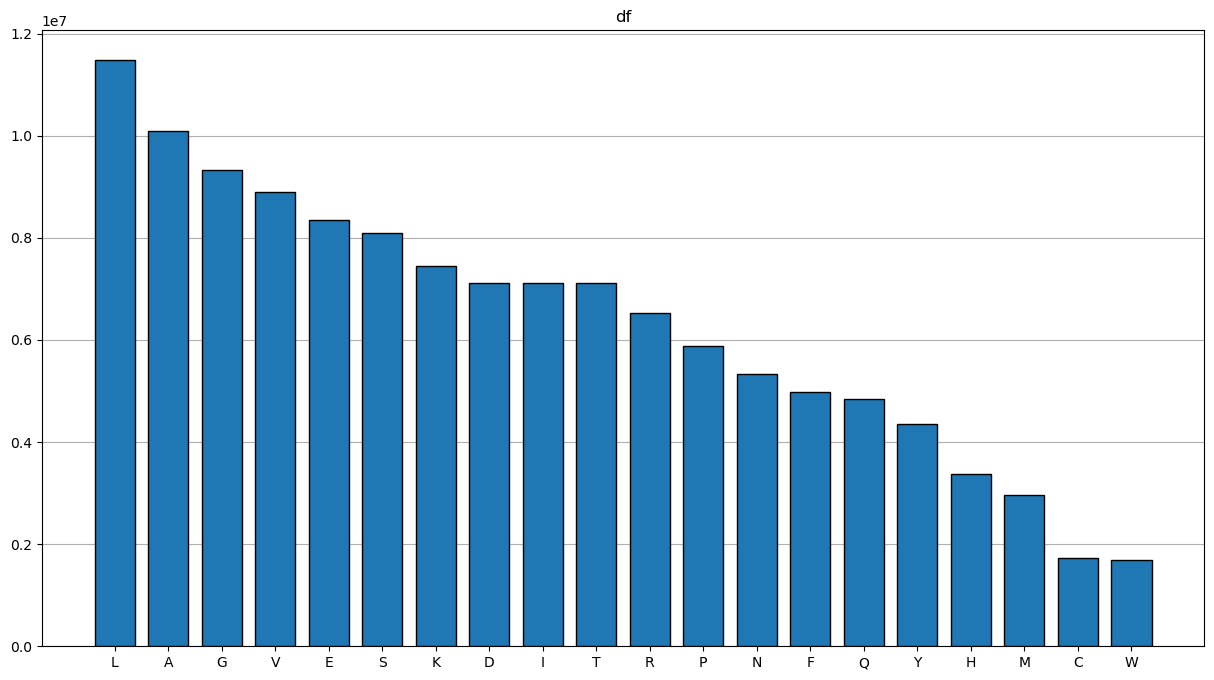

In [9]:
# Configure storage for DataFrame df
AA_counts = {'df': defaultdict(lambda: 0)}

# Count types for DataFrame df
for (seq, nonstd) in zip(df['seq'], df['has_nonstd_aa']):
    if not nonstd:
        for aa in set(seq):
            if aa != '*':
                AA_counts['df'][aa] += seq.count(aa)

# Sort amino acids by descending total abundance
total_aa = [AA_counts['df'][aa] for aa in AA_counts['df'].keys()]
temp = sorted(total_aa, reverse=True)
order = [total_aa.index(v) for v in temp]
aa_order = [list(AA_counts['df'].keys())[i] for i in order]

# Plot a comparison between datasets
fig, axs = plt.subplots(1, 1, figsize=(15, 8))

axs.bar(range(20), height=[AA_counts['df'][aa] for aa in aa_order],
        tick_label=aa_order, edgecolor='black', width=0.75, zorder=3)
axs.grid(axis='y', which='both', zorder=0)
axs.title.set_text('df')

fig.show() # Display the figure


In [14]:
from collections import defaultdict
import pandas as pd

# Configure storage for DataFrame df
AA_counts = {'df': defaultdict(lambda: 0)}

# Count types for DataFrame df
for (seq, nonstd) in zip(df['seq'], df['has_nonstd_aa']):
    if not nonstd:
        for aa in set(seq):
            if aa != '*':
                AA_counts['df'][aa] += seq.count(aa)

# Sort amino acids by descending total abundance
total_aa = [AA_counts['df'][aa] for aa in AA_counts['df'].keys()]
temp = sorted(total_aa, reverse=True)
order = [total_aa.index(v) for v in temp]
aa_order = [list(AA_counts['df'].keys())[i] for i in order]

# Show the proportion of each amino acid in a table
tbl_data = {'Amino Acid': aa_order,
            'df': [ round(AA_counts['df'][aa] / sum(AA_counts['df'].values()), 3) for aa in aa_order]}
pd.DataFrame(tbl_data)


,Amino Acid,df
0,L,0.091
1,A,0.080
2,G,0.074
3,V,0.070
4,E,0.066
5,S,0.064
6,K,0.059
7,D,0.056
8,I,0.056
9,T,0.056


# Adjusting Data Import for Model Usage

(477153, 7)


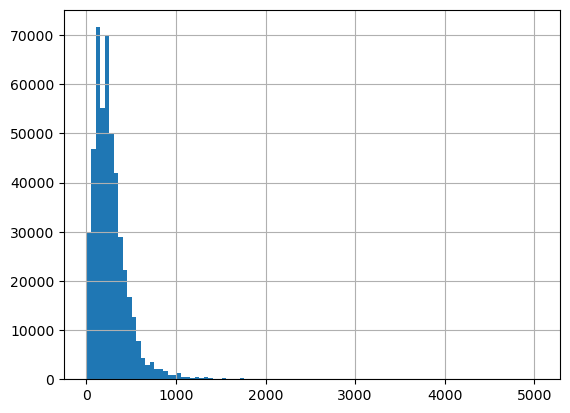

In [2]:
df = pd.read_csv(r"H:\\THESIS\\DATASET\\2022-08-03-ss.cleaned.csv")
df.len.hist(bins=100)
print(df.shape)

In [3]:
df.head()

,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa
0,1A30,C,EDL,CBC,CEC,3,False
1,1B05,B,KCK,CBC,CEC,3,False
2,1B0H,B,KAK,CBC,CEC,3,False
3,1B1H,B,KFK,CBC,CEC,3,False
4,1B2H,B,KAK,CBC,CEC,3,False


# Concept Behind the Prediction Methodology

# To demonstrate that the concept works, researchers used only protein sequences with less than 128 amino acids. They also applied an overlapping sliding window of size 3 to the input sequences. This artificially generated a corpus with many more distinct words (> 7,000 different n-grams compared to 20 amino acids). This approach is based on the principle that protein sequences can be represented as phrases composed of biological words.

In [4]:
def seq2ngrams(seqs, n=3):
    return np.array([[seq[i:i+n] for i in range(len(seq))] for seq in seqs])

In [5]:
# Define max sequence length and n-gram size
maxlen_seq = 128
n = 3  # n-gram size

# Filter sequences
input_seqs, target_seqs = df[['seq', 'sst3']][(df['len'] <= maxlen_seq) & (~df['has_nonstd_aa'])].values.T

# Generate n-grams
def seq2ngrams(seqs, n=3, maxlen=None):
    ngrams = [[seq[i:i+n] for i in range(len(seq) - n + 1)] for seq in seqs]
    if maxlen is not None:
        ngrams = [gram[:maxlen] + [''] * max(0, maxlen - len(gram)) for gram in ngrams]
    return ngrams

input_grams = seq2ngrams(input_seqs, n=n)
print("Number of input sequences:", len(input_seqs))
print("Example n-grams for the first sequence:", input_grams[0])


Number of input sequences: 103801
Example n-grams for the first sequence: ['EDL']


# Pre-processing

To prepare the text sequences for training and testing, I used Keras preprocessing tools to encode them as word classification numbers and one-hot. This means each word in the sequence is represented by a unique number, and each target sequence is represented by a vector of zeros and ones, with a single one indicating the correct word. To ensure all sequences have the same length, shorter sequences are padded with zeros.

In [10]:
tokenizer_encoder = Tokenizer()
tokenizer_encoder.fit_on_texts(input_grams)
input_data = tokenizer_encoder.texts_to_sequences(input_grams)
input_data = seq2ngrams.pad_sequence(input_data, maxlen=maxlen_seq, padding='post')

AttributeError: 'function' object has no attribute 'pad_sequence'

In [19]:
tokenizer_decoder = Tokenizer(char_level=True)
tokenizer_decoder.fit_on_texts(target_seqs)
target_data = tokenizer_decoder.texts_to_sequences(target_seqs)
target_data = seq.pad_sequences(target_data, maxlen=maxlen_seq, padding='post')
target_data = to_categorical(target_data)
input_data.shape, target_data.shape

((88751, 128), (88751, 128, 4))

# Modeling

This example is motivated by the NLP task of POS-tagging.

In [20]:
n_words = len(tokenizer_encoder.word_index) + 1
n_tags = len(tokenizer_decoder.word_index) + 1
print(n_words, n_tags)

8421 4


In [21]:
input = Input(shape=(maxlen_seq,))
x = Embedding(input_dim=n_words, output_dim=128, input_length=maxlen_seq)(input)
x = Bidirectional(LSTM(units=64, return_sequences=True, recurrent_dropout=0.1))(x)
y = TimeDistributed(Dense(n_tags, activation="softmax"))(x)

In [22]:

model = Model(input, y)
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 128)               0         
_________________________________________________________________
embedding_1 (Embedding)      (None, 128, 128)          1077888   
_________________________________________________________________
bidirectional_1 (Bidirection (None, 128, 128)          98816     
_________________________________________________________________
time_distributed_1 (TimeDist (None, 128, 4)            516       
Total params: 1,177,220
Trainable params: 1,177,220
Non-trainable params: 0
_________________________________________________________________


# Model Training and Evaluation
The model is trained to minimize the difference between model predictions and actual values. To evaluate the model's performance, Q3 accuracy is also calculated, which represents the percentage of correctly predicted encoding characters.

In [23]:
def q3_acc(y_true, y_pred):
    y = tf.argmax(y_true, axis=-1)
    y_ = tf.argmax(y_pred, axis=-1)
    mask = tf.greater(y, 0)
    return K.cast(K.equal(tf.boolean_mask(y, mask), tf.boolean_mask(y_, mask)), K.floatx())

In [24]:
model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy", q3_acc])

In [25]:
X_train, X_test, y_train, y_test = train_test_split(input_data, target_data, test_size=.4, random_state=0)
seq_train, seq_test, target_train, target_test = train_test_split(input_seqs, target_seqs, test_size=.4, random_state=0)

history = model.fit(X_train, y_train, batch_size=128, epochs=5, validation_data=(X_test, y_test), verbose=1)

Train on 53250 samples, validate on 35501 samples
Epoch 1/5
53250/53250 [==============================] - 173s 3ms/step - loss: 0.4143 - acc: 0.8251 - q3_acc: 0.7218 - val_loss: 0.3282 - val_acc: 0.8677 - val_q3_acc: 0.7903
Epoch 2/5
53250/53250 [==============================] - 164s 3ms/step - loss: 0.2886 - acc: 0.8855 - q3_acc: 0.8176 - val_loss: 0.2784 - val_acc: 0.8911 - val_q3_acc: 0.8275
Epoch 3/5
53250/53250 [==============================] - 164s 3ms/step - loss: 0.2556 - acc: 0.8996 - q3_acc: 0.8400 - val_loss: 0.2543 - val_acc: 0.9000 - val_q3_acc: 0.8416
Epoch 4/5
53250/53250 [==============================] - 163s 3ms/step - loss: 0.2314 - acc: 0.9094 - q3_acc: 0.8556 - val_loss: 0.2352 - val_acc: 0.9098 - val_q3_acc: 0.8571
Epoch 5/5
53250/53250 [==============================] - 162s 3ms/step - loss: 0.2124 - acc: 0.9173 - q3_acc: 0.8682 - val_loss: 0.2204 - val_acc: 0.9158 - val_q3_acc: 0.8666


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
y_pred = model.predict(X_test)

# If it's a classification problem and the outputs are probabilities, convert them to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Results

In this simple example, the model was trained quickly and achieved reasonable Q3 results. The next three examples show three training and three test examples. Each image shows the softmax activation (red) on top of the underlying one-hot ground truth (blue).

The following code is performing these tasks:

1. onehot_to_seq: This function converts a one-hot encoded sequence into a string. It does this by finding the index of the maximum value in each one-hot vector (representing a letter in the sequence), and then uses this index to find the corresponding letter in the provided dictionary. The sequence is terminated when it encounters the first zero, which is typically used for padding variable-length sequences.

2. plot_results: This function plots the model's prediction results. It prints the input sequence, the expected sequence, and the sequence predicted by the model. Then, it plots a heatmap of the expected and predicted sequences, where blue represents the expected sequence and red represents the predicted sequence.

3. revsere_decoder_index and revsere_encoder_index: These lines create reverse dictionaries for the decoder and encoder. This is useful for converting back from indices to letters.

4. Training and Testing: Here, the code is predicting the first N sequences from the training and test sets using the trained model, and then uses the plot_results function to visualize the results.

In [26]:
def onehot_to_seq(oh_seq, index):
    s = ''
    for o in oh_seq:
        i = np.argmax(o)
        if i != 0:
            s += index[i]
        else:
            break
    return s

In [27]:
def plot_results(x, y, y_):
    print("---")
    print("Input: " + str(x))
    print("Expected result: " + str(onehot_to_seq(y, revsere_decoder_index).upper()))
    print("Obtained result: " + str(onehot_to_seq(y_, revsere_decoder_index).upper()))
    fig = plt.figure(figsize=(10,2))
    plt.imshow(y.T, cmap='Blues')
    plt.imshow(y_.T, cmap='Reds', alpha=.5)
    plt.yticks(range(4), [' '] + [revsere_decoder_index[i+1].upper() for i in range(3)])
    plt.show()

Treinamento:
---
Entrada: MGDKPIWEQIGSSFINHYYQLFDNDRTQLGAIYIDASCLTWEGQQFQGKAAIVEKLSSLPFQKIQHSITAQDHQPTPDSCIISMVVGQLKADEDPIMGFHQEFLLKNINDAWVCTNDMFRLALHNFG
Resultado esperado: CCCCCHHHHHHHHHHHHHHHHHHHCHHHHHHHCCCCCEEEECCEEEECHHHHHHHHHHCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCCEEEEEEEEEEECCCCEEEEEEEEEEECCCCC
Resultado obtido: CCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHEEEEEEEEEECCEEEECHHHHHHHHHCCCCCCCEEEEEEEEEEECCCCCEEEEEEEEEEECCCCCEEEEEEEEEEEECCEEEEEEEEEEEECCCCC


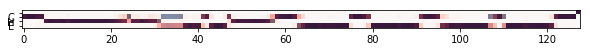

---
Entrada: SRGTQTE
Resultado esperado: CEEEECC
Resultado obtido: CCCCCCC


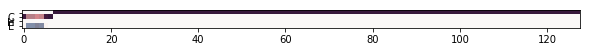

---
Entrada: MKEEKRSSTGFLVKQRAFLKLYMITMTEQERLYGLKLLKVLQSEFKEIGFKPNHTEVYRSLHELLDDGILKQIKVKKEGAKLQEVVLYQFKDYEAAKLYKKQLKVELDRCKKLIEKALSDNF
Resultado esperado: CCCCCCCCCCCCCCHHHHHHHHHHHHHHCCCEECCCCHHHHHHHHCCCCCCCCHHHHHHHHHHHHHCCCEEEEECCCCCCCCCCCEEEEECCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC
Resultado obtido: CCCCCCCCCCCCCHHHHHHHHHHHHHHHHHCCCHHHHHHHHHHHHHHCCCCCCCHHHHHHHHHHHHHCCCEEEEECCCCCCCCCEEEEEECCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC


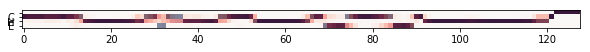

Teste:
---
Entrada: MKRQKRDRLERAHQRGYQAGIAGRSKEMCPYQTLNQRSQWLGGWREAMADRVVMAHHHHHH
Resultado esperado: CCCCCHHHHHHHHHHHHHHHHCCCCCCCCCCCCHHHHHHHHHHHHHHHHHCCCCCCCCCCC
Resultado obtido: CCCCCHHHHHHHHHHHHHHHHHCHCHCCCCCCHHHHHHHHHCCHHHHHHHHCCCCCCCCCC


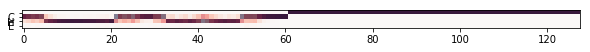

---
Entrada: YCQKWMWTCDEERKCCEGLVCRLWCKRIINM
Resultado esperado: CCCCCCCECCCCCCCCCCCECCCECECCCCC
Resultado obtido: CCCCCCEECCCCCCEEECCCCEEEEEEEEEC


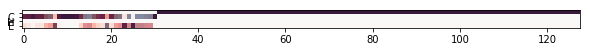

---
Entrada: TEFSEEQKRTLDLLFLFDRRMTEERRRWLSQRLGLNEEQIERWFRRKEQQI
Resultado esperado: CCCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHCCCCCC
Resultado obtido: CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHHHCCCC


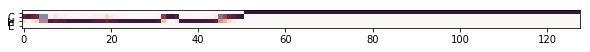

In [28]:
revsere_decoder_index = {value:key for key,value in tokenizer_decoder.word_index.items()}
revsere_encoder_index = {value:key for key,value in tokenizer_encoder.word_index.items()}

N=3
y_train_pred = model.predict(X_train[:N])
y_test_pred = model.predict(X_test[:N])
print('Training:')
for i in range(N):
    plot_results(seq_train[i], y_train[i], y_train_pred[i])
print('Test:')
for i in range(N):
    plot_results(seq_test[i], y_test[i], y_test_pred[i])

As can be seen in the heatmaps above, there are almost no sequences with blue shades (which are the expected values), so it is clear that our model was very capable of accurately predicting the protein sequences. The red shades almost completely overlap the blue ones.

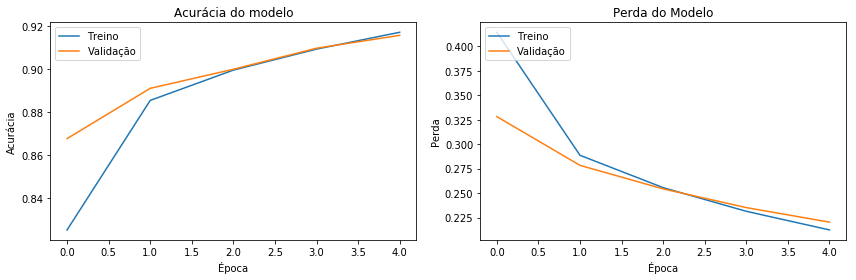

In [29]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

O modelo performou bem com acurácia proxima de 92%, não há indícios de overfitting. Portanto, o modelo conseguiu prever bem as estruturas secundárias de proteínas. 